Ejecuta la siguiente celda para importar las librerías de Python y que se puedan ejecutar las simulaciones

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button
from matplotlib.animation import FuncAnimation
from scipy.integrate import quad

<h1 align="center"> <b> Entrega de Procesos Estocásticos </b> </h1>

---
<h2 align="center"> <u> Análisis de la bifurcación supercrítica </u> </h2>

<h3> <b> Enunciado: </b></h3>

Considera la ecuación diferencial estocástica de Stratonovich:

$$
\dot{x}(t) = ax-x^3+\sqrt{D}\xi(t)
$$

donde $\xi(t)$ es un ruido blanco de media cero y correlación $\langle\xi(t)\xi(t')\rangle = \delta(t-t')$. Se te pide:

1. Escribe la correspondiente ecuación de Fokker-Plank

2. Bajo la condición de corriente cero, encuentra la distribución de probabilidad estacionaria $f_{st}(x)$ (no necesitas calcular la constante de normalización).

3. Escribe el potencial para la solución estacionaria.

4. Comenta cómo la forma de la distribución de probabilidad estacionaria varía al cambiar el parámetro $a$. Compara con el diagrama de bifurcación de la bifurcación supercrítica de horca (*pitchfork*) $\dot{x}(t) = ax-x^3$.

5. Genera muchas trayectorias del proceso estocástico numéricamente y empléalas para calcular la distribución de probabilidad estacionaria, comparando con la predición teórica.

<h3> <b> Ecuación de Fokker-Plank y distribución de probabilidad estacionaria </b></h3>

Al tratarse de un proceso estocástico de ruido aditivo la ecuación de Fokker-Plank en prescripción Itô y Stratonovich son equivalentes, que para una ecuación de Langevin de la forma

$$
\dot{x}(t) = A(x, t) + B(t)\xi(t)
$$

es la siguiente

$$
\frac{\partial f}{\partial t} = -\frac{\partial}{\partial x}\left[ A(x, t)f(x, t) \right] + \frac{1}{2} \frac{\partial^2}{\partial x^2}\left[ B^2(t)f(x, t) \right]
$$

que sustituyendo las expresiones de $A(x, t) = ax-x^3$ y $B(t) = \sqrt{D}$ y distribuyendo la derivada del producto obtenemos

$$
\boxed{
\frac{\partial f}{\partial t} = -\left(a-3x^2\right)f - \left(ax-x^3\right) \frac{\partial f}{\partial x} + \frac{1}{2} D \frac{\partial^2 f}{\partial x^2}
}
$$

Otra forma de la ecuación de Fokker-Plank es la de ecuación de continuidad

$$
\frac{\partial f}{\partial t} = -\frac{\partial J}{\partial x}
$$

donde $J$ es una corriente de probabilidad. El caso $J = 0$ se traduce, por tanto, a 

$$
\begin{array}{c}
\left(ax-x^3\right)f_{st}-\frac{1}{2}D\frac{\partial f_{st}}{\partial x} = 0\\
 \Downarrow\\ 
 \frac{d f_{st}}{f_{st}} = \frac{2}{D}\left( ax - x^3\right)dx\\
 \Downarrow\\
 \boxed{
 f_{st}(x) = A\exp\left(2\frac{\frac{1}{2}ax^2-\frac{1}{4}x^4}{D}\right)
 }
 \end{array}
$$

<h3> <b> Potencial: </b></h3>

Suponer que el sistema está sometido a un potencial $V(x)$ significa que la evolución de la posición viene dada por 

$$
\dot{x}(t) = \frac{dV}{dx} +\sqrt{D}\xi(t)
$$

por lo que el equivalente al potencial en este caso sería 

$$
\boxed{
V(x) = -\frac{1}{2}ax^2+\frac{1}{4}x^4
}
$$

Los mínimos del potencial vienen dados por $V'(x) = 0$ y $V''(x) > 0$ que en este caso se dan en 

$$
\begin{cases}
0 \quad , \; a<0\\
\pm \sqrt{a} \quad , \; a\ge 0
\end{cases}
$$

Por lo que cuando $a<0$ aparece tan solo un mínimo estable en $x=0$, mientras que al aumentar $a$ y pasar a ser $a>0$ el punto $x=0$ pasa de ser un mínimo a ser un máximo y aparecen dos mínimos en $a = \pm \sqrt{a}$, un proceso similar a como en los sistemas con una bifurcaión de tipo *pitchfork* el punto estable se transfoma en dos estables y uno inestable al variar el parámetro de control. En este caso los puntos fijos estables se corresponden con los mínimos del potencial, que se traducen como máximos en la distribución de probabilidad estacionaria ya que son puntos que *absorben* a los que se encuentran cerca de ellos, y los puntos fijos inestables que son los máximos del potencial, resultan mínimos  de la distribución de probabilidad ya que *repelen* a los puntos cerca de sí, por lo que dependiendo del valor de $a$ observaremos cómo la pdf pasa de ser monomodal con un solo máximo cuando $a<0$ a ser bimodal con dos máximos cuando $a>0$.

# Simulación

La siguiente es una simulación interactiva (requiere tener instalado ``ipympl``) en la que se puede observar cómo se obtiene la distribución de probabilida estacionaria teórica cuando $N$ es muy grande y cuando pasa el suficiente tiempo como para que el transitorio desaparezca. En la figura inferior se muestran $N$ partículas cuyo movimiento viene gobernado por la SDE mientras que en la de arriba se muestra el histograma con las posiciones de dichas partículas frente a la distribución de probabilidad teórica para la $a$ y $D$ seleccionadas.

## Parámetros:
- **D**: intensidad del ruido que determina cuán *ancha* es la distribución o si hay mucha difusión debida al ruido.
- **a**: parámetro de control de la distribución que determina si es monomodal o bimodal y cómo de juntos están los picos
- **N**: número de prtículas. Cuando sea umenta $N$ con el deslizador se generan partículas en posiciones dadas por una distribución $\mathcal{N}(0, 1)$.

<div class="alert alert-info">

<b>💡 Consejo:</b> es divertido ver cómo al cambiar rápidamente de $ a < 0 $ a $ a > 0 $ las partículas se dividen en dos grupos y cómo al revés van todas *corriendo* al centro a juntarse en torno al máximo de la pdf.

</div>

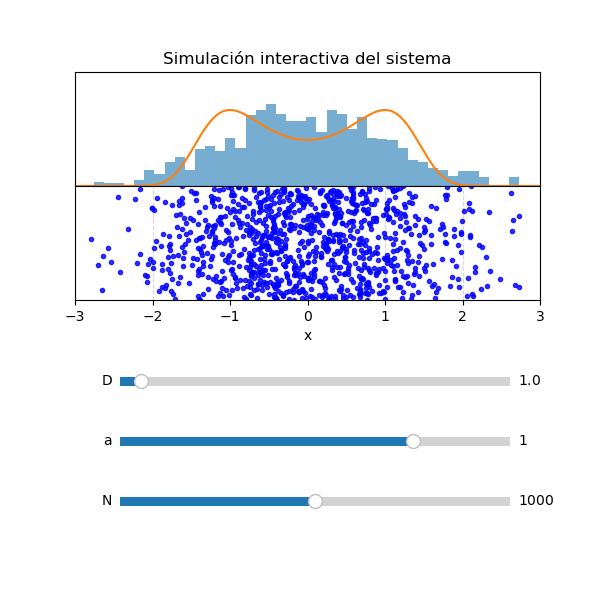

In [81]:
%matplotlib widget
# 1. Definimos el sistema de ecuaciones diferenciales estocásticas
def actualizar_posiciones(X, a, D, dt=0.005):
    N = X.shape[0]
    dxdt = a * X - X**3 + np.sqrt(D) * np.random.standard_normal(N) / np.sqrt(dt)
    X_nuevo = X + dt * dxdt

    return X_nuevo

# Configuración inicial de la simulación
N_init = 1000
a_init = 1
D_init = 1
X = np.random.standard_normal(N_init)
Y = np.arange(N_init)

def pdf(x, a, D):
    x_array = np.asarray(x)
    func_nnorm = lambda t: np.exp((a * t**2 - 0.5 * t**4) / D)
    norma, error = quad(func_nnorm, -np.inf, np.inf)
    resultado = func_nnorm(x_array) / norma
    return resultado

# Configuración de la ventana gráfica
plt.close()
fig, [ax_hist, ax_dots] = plt.subplots(nrows=2, figsize=(6, 6))
plt.subplots_adjust(bottom=0.5, hspace=0)

puntos, = ax_dots.plot(X, Y, 'b.', alpha=0.8)
ax_dots.set_xlim(-3, 3)
ax_dots.set_ylim(0, N_init)
ax_dots.grid(True, linestyle='--', alpha=0.5)
ax_dots.set_yticks([])
ax_dots.set_xlabel("x")

pesos_iniciales, bins, patches = ax_hist.hist(X, bins=50, density=True, alpha=0.6)
x_range = np.linspace(-3, 3, 1000)
pdf_plot, = ax_hist.plot(x_range, pdf(x_range, a_init, D_init))

ax_hist.set_xlim(-3, 3)
ymax = pdf(x_range, a_init, D_init).max()
ax_hist.set_ylim(0, ymax * 1.5)

ax_hist.set_xticks([])
ax_hist.set_yticks([])
ax_hist.set_title("Simulación interactiva del sistema")

# Creación de los sliders
ax_a = plt.axes([0.2, 0.25, 0.65, 0.03])
ax_D = plt.axes([0.2, 0.35, 0.65, 0.03])
ax_N = plt.axes([0.2, 0.15, 0.65, 0.03])
plt.text(5, 0.1, r"SDE: $\dot{x} = ax-x^3 + \sqrt{D}\xi(t)$", ha='center')

slider_a = Slider(ax=ax_a, label="a", valmin=-2, valmax=2, valinit=a_init)
slider_D = Slider(ax=ax_D, label="D", valmin=0.5, valmax=10, valinit=D_init)
slider_N = Slider(ax=ax_N, label="N", valmin=0, valmax=2000, valinit=N_init, valstep=10)

# Creación de la animación
def update(frame):
    global X, Y
    a = slider_a.val
    D = slider_D.val
    N_actual = len(X)
    N_nuevo = int(slider_N.val)

    if N_nuevo < N_actual:
        X = X[:N_nuevo]
    elif N_nuevo > N_actual:
        N_faltante = N_nuevo - N_actual
        X_faltante = np.random.standard_normal(N_faltante)
        X = np.concatenate((X, X_faltante))

    X = actualizar_posiciones(X, a, D)
    if N_nuevo != N_actual:
        Y = np.arange(N_nuevo)
        if N_nuevo == 0:
            ax_dots.set_ylim(0, 10)
        else:
            ax_dots.set_ylim(0, N_nuevo)

    puntos.set_data(X, Y)
    pdf_plot.set_data(x_range, pdf(x_range, a, D))
    ymax = pdf(x_range, a, D).max()
    ax_hist.set_ylim(0, ymax * 1.5)

    with np.errstate(divide='ignore', invalid='ignore'):
        nuevas_alturas, _ = np.histogram(X, bins=bins, density=True)
    nuevas_alturas = np.nan_to_num(nuevas_alturas)

    for patch, altura in zip(patches, nuevas_alturas):
        patch.set_height(altura)
    
    return puntos, *patches, pdf_plot

animation = FuncAnimation(fig, update, interval=20, cache_frame_data=False)

plt.show()


---

<h2 align="center"> <u> Procesos estocásticos dentro de la célula </u> </h2>

<h3> <b> Enunciado: </b></h3>

Uno de los procesos fundamentales dentro de la célula es la transcripción de gener, el cual convierte una pequeña porción de ADN en ARNm. Después de este proceso el ARNm deja el núcleo y se mueve en torno al citoplasma, donde los ribosomas se pegan a él y el proceso de traducción de proteinas comienza. En este ejercicio proponemos que se estudie el proceso estocástico de transcripción de genes en términos de un conjunto simple  de reacciones químicas. Estas reacciones químicas son transcripciones de genes a ARNm con una tasa $\omega_T$ y la degradación de ARNm con una tasa $\gamma$:

$$
R_1: \; A \overset{\omega_T}{\rightarrow}ARNm \; R_2: \; ARNm \overset{\gamma}{\rightarrow} \varnothing
$$

Se te pide:

1. Escribir la Ecuación Maestra que describe la probabilidad de tener $n$ moléculas de ARNm a tiempo $t$ (asuma que el númeero de partículas de tipo $A$ no cambia, por tanto actuando como reserva).

2. Encuentra la solución de la Ecuación Maestra: qué distribución de probabilidad se obtiene?

3. Escribir la ecuación de Fokker-Planck obtenida al efectuar la expansión de Kramers-Moyal en términos el tamaño del sistema $N$ (Suponga que las tasas de transición son proporcionales al tamaño del sistema $N$).

4. Resolver la ecuación de Fokker-Planck para el caso de cirriente 0. ¿Qué distribución se obtiene? ¿Por qué? Escriba el potencial para la solución estaicionaria. 

5. Escribir la ecuación diferencial estocástica asociada con la ecuación de Fokker-Planck. Calcule la solución para el límite determinista. Calcula también la solución estacionaria

6. Simular el proceso estocástico usando el algoritmo de Guillespie. Compare con la solución determinista para valores cada vez más grandes del tamaño del sistema $N$.

---

<h3><b> Ecuación Maestra y solución discreta </b></h3>

Los procesos que se pueden dar que cambien el estado del sistema de tener $n$ moléculas a $n \pm 1$ moléculas y viceversa (nos quedamos tan solo a procesos de primer orden) son los siguientes
$$
\begin{align*}
n+1 &\overset{\gamma}{\longrightarrow} n\\
n-1 &\overset{\omega_T}{\longrightarrow} n\\
n &\overset{\gamma}{\longrightarrow} n-1\\
n &\overset{\omega_T}{\longrightarrow} n+1\\
\end{align*}
$$

Por lo que como la degradación depende del número de moléculas que haya en ese momento para poder degradarse pero la transcripción no, ya que el número de $A$ es constante la ecuación maestra es la siguiente

$$
\boxed{
    \frac{dP(n, t)}{dt} = (n+1)\gamma P(n+1, t) + \omega_T P(n-1, t) - n\gamma P(n, t) - \omega_T P(n, t)
}
$$

Para encontrar la distribución estacionaria tomamos $\frac{dP(n, t)}{dt} = 0$ y despejando $P(n+1, t)$ obtenemos

$$
P_{st}(n+1) = \frac{n\gamma P_{st}(n) + \omega_T P_{st}(n) - \omega_T P_{st}(n-1)}{\gamma(n+1)}
$$

Por consistencia con lo esperado vamos a supones que el flujo de probabilidad también es 0, igual que lo que solemos hacer en el caso continuo, lo que implica que las tasas de transcripción $n-1 \overset{\omega_T}{\longrightarrow} n$ y degradación $n \overset{\gamma}{\longrightarrow} n-1$ se igualan, lo qu implica $\omega_T P_{st}(n-1) = n\gamma P_{st}(n) $, que al sustituirlo en nuestra ecuación anterior implica

$$
P_{st}(n+1) = \frac{\omega_T P_{st}(n)}{(n+1)\gamma}
$$

que desarrollando hasta $ P_{st}(0) $ y llamando $ \alpha = \frac{\omega_T}{\gamma} $ obtenemos

$$
P_{st}(n) = \frac{\alpha^n}{n!}P_{st}(0)
$$

normalizando $P_{st} $ 

$$
\sum_{n=0}^\infty P_{st}(n) = \sum_{n=0}^\infty \frac{\alpha^n}{n!}P_{st}(0) = e^\alpha P(0) = 1 \Rightarrow P(0) = e^{-\alpha}
$$

por lo que la distribución estacionaria discreta es una distribución de Poisson de parámetro $\alpha$ 

$$
\boxed{
P(n) = \frac{\alpha^n}{n!}e^{-\alpha}
}
$$

al ser $\alpha$ el ratio entre la tasa de transcripción y de degradación, cuando $\alpha<1$ querrá decir que la tasa de transcripción será menor que la de degradación, por lo que el estado más probable será el de $n = 0$, mientras que para $\alpha < 1$ la transcripción será más probable que la degradación hasta un tamaño del sistema tal que $n\gamma > \omega$, lo que implica que como el reservorio de $A$ es finito, una vez que el número de proteinas ha superado un tamaño crítico la probabilidad de degradarse es mayor que la de trascribir, por lo que empezará a decrecer $P_{st}$ 

Para mostrar la simulación ejecuta la siguiente celda de código.

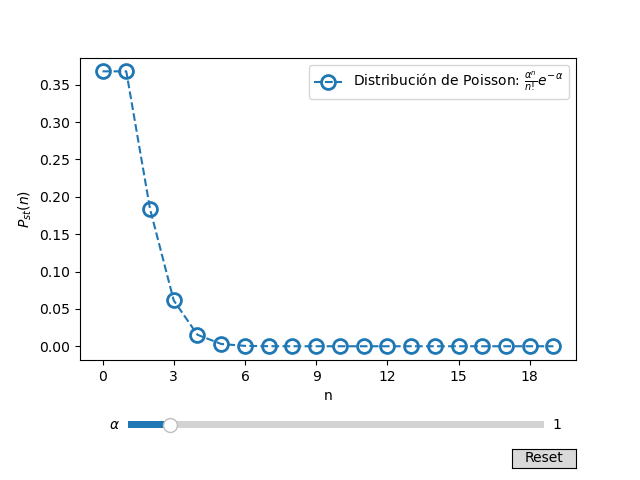

In [82]:
from scipy.stats import poisson
import matplotlib.ticker as ticker
%matplotlib widget

n = np.arange(20)
alpha_init = 1

plt.close()

fig, ax = plt.subplots()

line, = ax.plot(n, poisson.pmf(n, alpha_init), 
                marker='o', 
                ls='--', 
                ms=10, 
                fillstyle='none', 
                markeredgewidth=2,
                label=r"Distribución de Poisson: $\frac{\alpha^n}{n!}e^{-\alpha}$"
                )
ax.set_xlabel("n")
ax.set_ylabel(r"$P_{st}(n)$")
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
fig.subplots_adjust(bottom=0.25)

ax_alpha = fig.add_axes([0.2, 0.1, 0.65, 0.03])
alpha_slider = Slider(ax_alpha, label=r"$\alpha$", valmin=0, valmax=10, valinit=alpha_init)

def update(val):
    line.set_ydata(poisson.pmf(n, val))
    fig.canvas.draw_idle()

alpha_slider.on_changed(update)

resetax = fig.add_axes([0.8, 0.025, 0.1, 0.04])
button = Button(resetax, 'Reset', hovercolor='0.975')

def reset(event):
    alpha_slider.reset()
button.on_clicked(reset)

ax.legend(loc='upper right')
plt.show()

<h3><b> Ecuación de Fokker Planck y solución continua </b></h3>

Para pasar al caso continuo suponemos un tamaño del sistema $N \ll 1$, y hacemos el cambio de variable $ n = xN $ donde $ x $ es la fracción de moléculas de ARNm, por lo que la Ecuación Maestra quedaría como

$$
\frac{\partial P(x, t)}{\partial t} = N\left(x+\frac{1}{N}\right)\gamma P\left(x+\textstyle{\frac{1}{N}}, t\right) + \omega_T P\left(x-\textstyle{\frac{1}{N}}, t\right) - Nx\gamma P(x, t) - \omega_T P(x, t)
$$

Vamos a renombrar variables como $ \gamma(x) = Nx\gamma $ y $\omega_T = \tilde{\omega}_T N$ para poder simplificar la ecuación y desarrollar lo términos en serie de Taylor hasta el segundo orden (expansión de Kramers-Moyal)

$$
\gamma\left(x+\frac{1}{N}\right)P\left(x+\textstyle{\frac{1}{N}}\right) = \gamma(x)P(x, t) + \frac{1}{N}\frac{\partial}{\partial x}\left[\gamma(x)P(x,t)\right] + \frac{1}{2N^2}\frac{\partial^2}{\partial x^2}\left[\gamma(x)P(x,t)\right]
$$

sustituyendo esta expansión y la de $P\left(x-\textstyle{\frac{1}{N}}, t\right)$ en la ecuación anterior y sustituyendo $\gamma(x) = Nx\gamma$ y $ \omega_T = N\tilde{\omega}_T $ obtenemos la ecuación de Fokker-Plack

$$
\boxed{
\frac{\partial P(x, t)}{\partial t} = -\frac{\partial}{\partial x}\left[ (\tilde{\omega}_T - \gamma x)P \right] + \frac{1}{2}\frac{\partial^2}{\partial x^2}\left[\frac{\tilde{\omega}_T + \gamma x}{N}P\right]
}
$$

en la que para obtener la solución estacionaria y de corriente 0 tomamos $\frac{\partial P(x, t)}{\partial t}=-\frac{\partial J}{\partial x} = 0$ y $J=0$, por lo que hay que resolver 

$$
-(\tilde{\omega}_T - \gamma x )P_{st}(x)+\frac{1}{2}\frac{d}{d x}\left[\frac{\tilde{\omega}_T + \gamma x}{N}P{st}(x)\right] = 0
$$

resolvemos para $P_{st}(x)$

$$
(\tilde{\omega}_T - \gamma x)P_{st}(x) = \frac{\gamma}{2N}P_{st}(x) + \frac{\tilde{\omega}_T+\gamma x}{2N}\frac{d P_{st}(x)}{d x} \Rightarrow d \ln P_{st}(x) = \left( \frac{4N\tilde{\omega}_T - \gamma}{\tilde{\omega}_T + \gamma x} -2N \right)dx
$$

obteniendo al integrar y al sustituir $\alpha = \frac{\tilde{\omega}_T}{\gamma}$ 

$$
P_{st}(x) = A(x + \alpha)^{4N\alpha-1}e^{-2Nx}
$$

La cual se trata de una distribución gamma desplazada $\alpha$. Conociendo la normalización de la distribución gamma podemos determinar el valor de $A$ 

$$
\boxed{
    P_{st}(x) = \frac{(2N)^{4N\alpha}}{\Gamma(4N\alpha)}(x+\alpha)^{4N\alpha - 1}e^{-2N(x+\alpha)}
}
$$

Por lo que se trata de una distribución gamma desplazada con parámetro de forma $4N\alpha$ y parámetro de tasa $2N$. La media de la dsitribución es $\alpha$, lo cual también puede ser obtenido sabiendo que en el caso de flujo de probabilidad 0 la tasa de transcripción se iguala con la de degradación, por lo que $\tilde{\omega}_T= \gamma x$, por lo que en el estado estacionario el promedio de las concentraciones será $x = \frac{\tilde{\omega}_T}{\gamma} $. En el límite termodinámico $N\rightarrow \infty$, que es en el que trabajamos, la distribución $ P_{st}(x) $ converge a la distribución normal (la demostración la subo a parte), y converge exactamente a la misma distribución normal que a la que converge la de Poisson para el límite termodinámico, por lo que en realidad la distribución que modela el sistema no es una gamma sino una normal ya que para llevar a cabo la derivación hemos necesitado suponer $N \rightarrow \infty$.

Para mostrar la simulación ejecuta la siguiente celda de código.

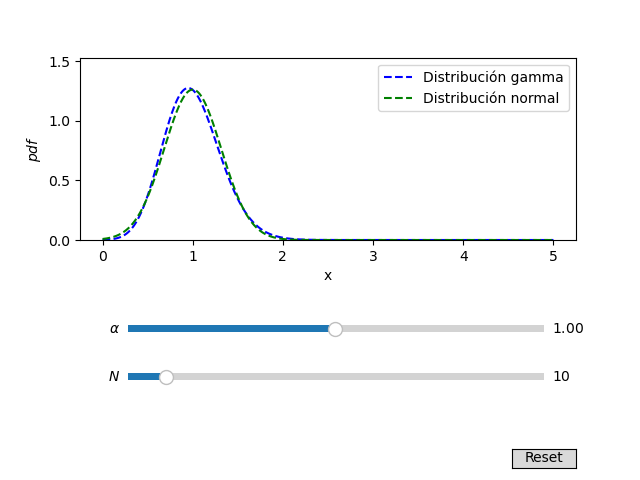

In [80]:
from scipy.stats import gamma, norm
import matplotlib.ticker as ticker

%matplotlib widget

N_init = 10
alpha_init = 1
x = np.linspace(0, 5, 1000)
a_gamma_init = 4 * N_init * alpha_init
b_gamma_init = 2 * N_init

plt.close()

fig, ax = plt.subplots()

gamma_plot, = ax.plot(x, gamma.pdf(x, a_gamma_init, loc=-alpha_init, scale=1/b_gamma_init), color='blue', ls='--', label=r"Distribución gamma")
normal_plot, = ax.plot(x, norm.pdf(x, loc=alpha_init, scale=np.sqrt(alpha_init/N_init)), color='green', ls='--', label=r"Distribución normal")

y_max = np.max([gamma.pdf(x, a_gamma_init, loc=-alpha_init, scale=1/b_gamma_init), norm.pdf(x, loc=alpha_init, scale=np.sqrt(alpha_init/N_init))])
ax.set_ylim(0, 1.2 * y_max)

ax.set_xlabel("x")
ax.set_ylabel(r"$pdf$")
fig.subplots_adjust(bottom=0.5)

ax_alpha = fig.add_axes([0.2, 0.3, 0.65, 0.03])
ax_N = fig.add_axes([0.2, 0.2, 0.65, 0.03])
alpha_slider = Slider(ax_alpha, label=r"$\alpha$", valmin=0.01, valmax=2, valinit=alpha_init)
N_slider = Slider(ax_N, label=r"$N$", valmin=1, valmax=100, valinit=N_init, valstep=1)

def update_N(N):
    alpha = alpha_slider.val
    a_gamma = 4 * N * alpha
    b_gamma = 2 * N
    gamma_plot.set_ydata(gamma.pdf(x, a_gamma, loc=-alpha, scale=1/b_gamma))
    normal_plot.set_ydata(norm.pdf(x, loc=alpha, scale=np.sqrt(alpha/N)))
    y_max = np.max([gamma.pdf(x, a_gamma, loc=-alpha, scale=1/b_gamma), norm.pdf(x, loc=alpha, scale=np.sqrt(alpha/N))])
    ax.set_ylim(0, 1.2 * y_max)

    fig.canvas.draw_idle()

def update_alpha(alpha):
    N = N_slider.val
    a_gamma = 4 * N * alpha
    b_gamma = 2 * N
    gamma_plot.set_ydata(gamma.pdf(x, a_gamma, loc=-alpha, scale=1/b_gamma))
    normal_plot.set_ydata(norm.pdf(x, loc=alpha, scale=np.sqrt(alpha/N)))
    y_max = np.max([gamma.pdf(x, a_gamma, loc=-alpha, scale=1/b_gamma), norm.pdf(x, loc=alpha, scale=np.sqrt(alpha/N))])
    ax.set_ylim(0, 1.2 * y_max)
    
    fig.canvas.draw_idle()

alpha_slider.on_changed(update_alpha)
N_slider.on_changed(update_N)

resetax = fig.add_axes([0.8, 0.025, 0.1, 0.04])
button = Button(resetax, 'Reset', hovercolor='0.975')

def reset(event):
    alpha_slider.reset()
    N_slider.reset()
button.on_clicked(reset)

ax.legend(loc='upper right')
plt.show()

<h3><b>EDE y método de Guillespie</b></h3>

A partir de la ecuación de Fokker-PLank podemos obtener la ecuación de Langevin asociada mediante prescripción de Itô, ya que la expansión de Kramers-Moyal genera una EFP que es muy fácil de emparejar con la que se traduce de una SDE mediante prescripción de Itô.

Comparando la EFP obtenida antes con una en la prescripción de Itô

$$
\frac{\partial P(x,t)}{\partial t} = -\frac{\partial}{\partial x}[A(x,t)P(x,t)] + \frac{1}{2}\frac{\partial^2}{\partial x^2}\left[B(x,t)^2P(x,t)\right]
$$

obtenemos los términos de $\emph{drift}$ y de difusión 

$$
\begin{align*}
A(x, t) &= \tilde{\omega}_T - \gamma x\\
B(x, t) &= \sqrt{\frac{\tilde{\omega}_T + \gamma x}{N}}
\end{align*}
$$

con lo que la EDE queda como

$$
\boxed{
    \dot{x} = \tilde{\omega}_T - \gamma x + \sqrt{\frac{\tilde{\omega}_T + \gamma x}{N}}\xi(t)
}
$$

En el límite termodinámico las fluctuaciones debido al ruido se hacen 0 ya que el término de difusión decrece con $N$, por lo que el caso determinista será 

$$
\dot{x} = \tilde{\omega}_T - \gamma x, \quad y = x - \underbrace{\frac{\tilde{\omega}_T}{\gamma}}_{\alpha} \Rightarrow \dot{y} = -\gamma y \Rightarrow  y(t) = y(0)e^{-\gamma t} \Rightarrow \boxed{x(t) = x(0)e^{-\gamma t} + \alpha\left(1-e^{-\gamma t}\right)}
$$

Por lo que en el caso estacionario $t\rightarrow \infty$ la concentración converge a $\alpha$, justo lo que se esperaba.


---
<h3><b>Simulación</b></h3>

Implementación del algoritmo de Gillespie para simular las reacciones.

<h4> Parámetros </h4>

- **gamma $(\gamma)$:** tasa de degradación del mRNA
- **omega $(\tilde{\omega}_T)$:** tasa de transcripción del mRNA
- **N_total:** tamaño del sistema

Al cambiar los valores de `gamma` y `omega` la simulación tenderá en el estado estacionario a `omega/gamma` con una varianza proporcional a `1/N_total`. Cambia los valores para ver cómo el tamaño del sistema modifica la varianza de la distribución en torno al valor promedio y cómo este valor cambia al variar las tasas de las reacciones.

In [ ]:
gamma = 1
omega = 2
N_total = [10, 100, 1000]

# Una vez cambiados los parámetros ejecuta la celda siguiente y espera a que se muestre la gráfica

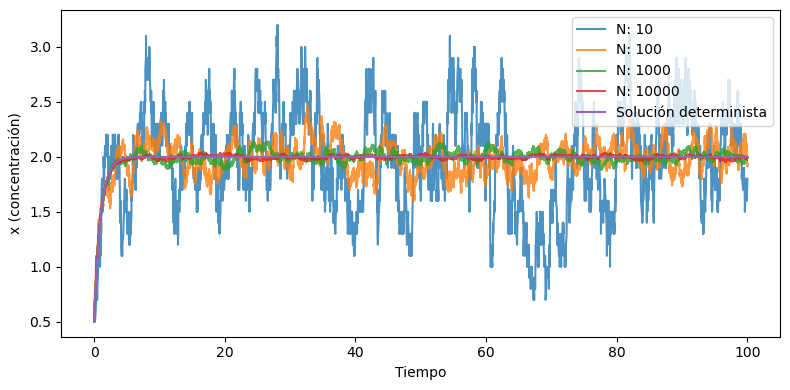

In [77]:
def gillespie(x_0=0.5, t_0=0, gamma=1.0, omega=2.0, N_total=1000, end_time=100, max_steps=300_000):
    time_array = np.zeros(max_steps)
    x_array = np.zeros(max_steps)
    x_array[0] = x_0
    time_array[0] = t_0

    x = x_0
    time = t_0

    i = 1
    while time < end_time and i < max_steps - 1:
        a1 = omega * N_total
        a2 = gamma * x * N_total
        a0 = a1 + a2

        r1 = np.random.random_sample()
        tau = -np.log(r1)/a0
        time = time + tau

        time_array[i] = time

        r2 = np.random.random_sample()
        target = r2 * a0
        if target < a1:
            x = x+1/N_total
        else:
            x = x-1/N_total

        x_array[i] = x
        i += 1

    time_array = time_array[:i]
    x_array = x_array[:i]

    return time_array, x_array

%matplotlib inline

plt.close()
fig, ax = plt.subplots(figsize=(8, 4))

x_0 = 0.5
t_0 = 0

end_time = 100
max_steps = 5_000_000

for N in N_total:
    time_array, x_array = gillespie(x_0, t_0, gamma, omega, N, end_time, max_steps)
    ax.plot(time_array, x_array, alpha=0.8, label=f"N: {N}", rasterized=True)

time_array = np.linspace(t_0, end_time, 1000)
deterministic = x_array[0] * np.exp(-gamma * time_array) + omega / gamma * (1-np.exp(-gamma * time_array))
ax.plot(time_array, deterministic, label="Solución determinista")
plt.legend(loc='upper right', bbox_to_anchor=(1, 1))
ax.set_xlabel("Tiempo")
ax.set_ylabel("x (concentración)")
plt.tight_layout()
plt.show()
